# Final Project by Gavriel Blau

The dataset that I am analyzing for the final project is a heart attack prediction dataset. I will explore the relationships between different varaibles and the probability of a person having a heart attack.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from collections import Counter
import numpy as np
from scipy.stats import lognorm
from scipy.stats import norm
from scipy.stats import pearsonr
from scipy.stats import kurtosis, skew
from scipy.stats import ttest_ind
import statsmodels.api as sm

In [2]:
# Load the dataset
file_path = 'C:/Users/chezk/OneDrive/Documents/bellevue class 4/heart.csv'
df = pd.read_csv(file_path)

In [3]:
print(df.columns)

Index(['age', 'sex', 'cp', 'trtbps', 'chol', 'fbs', 'restecg', 'thalachh',
       'exng', 'oldpeak', 'slp', 'caa', 'thall', 'output'],
      dtype='object')


In [4]:
# List of columns to plot histograms for
columns_of_interest = ['age', 'chol', 'oldpeak', 'thalachh', 'trtbps']

C:\Users\chezk\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\chezk\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\chezk\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\chezk\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating

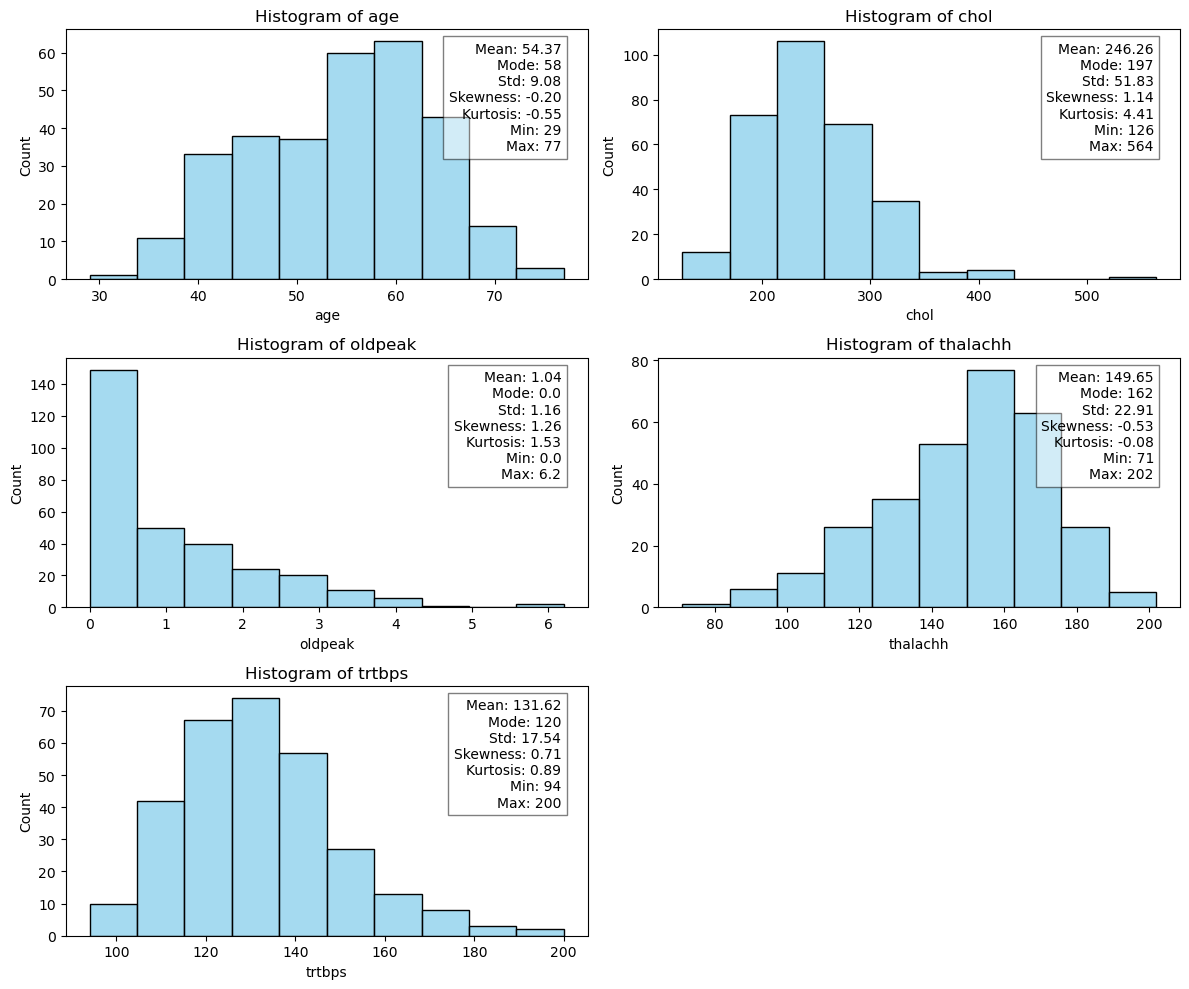

In [5]:
# Function to add text with descriptive statistics to histograms
def add_descriptive_stats(ax, series):
    mean_val = series.mean()
    mode_val = series.mode()[0]
    std_val = series.std()
    skewness = skew(series)
    kurt = kurtosis(series)
    min_val = series.min()
    max_val = series.max()

    textstr = (f'Mean: {mean_val:.2f}\nMode: {mode_val}\nStd: {std_val:.2f}\n'
               f'Skewness: {skewness:.2f}\nKurtosis: {kurt:.2f}\n'
               f'Min: {min_val}\nMax: {max_val}')

    ax.text(0.95, 0.95, textstr, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', horizontalalignment='right', bbox=dict(facecolor='white', alpha=0.5))

# Plot histograms for each column with descriptive statistics
fig, axs = plt.subplots(3, 2, figsize=(12, 10))
axs = axs.flatten()

for i, column in enumerate(columns_of_interest):
    sns.histplot(df[column], bins=10, color='skyblue', kde=False, ax=axs[i], edgecolor='black')
    axs[i].set_title(f'Histogram of {column}')
    add_descriptive_stats(axs[i], df[column])

# Remove any empty subplot if there are fewer than 6 columns
if len(columns_of_interest) < len(axs):
    fig.delaxes(axs[-1])

plt.tight_layout()
plt.show()

The extreme values of cholesterol and old peak appear to be errors will proceed to remove the outliers.

In [6]:
# Determine thresholds for extreme values (e.g., 95th percentile)
threshold_col1 = df['chol'].quantile(0.95)
threshold_col2 = df['oldpeak'].quantile(0.95)

# Filter out extreme values
# Filter out extreme values and overwrite the original df
df = df[(df['chol'] <= threshold_col1) & (df['oldpeak'] <= threshold_col2)]



make pmf graphs

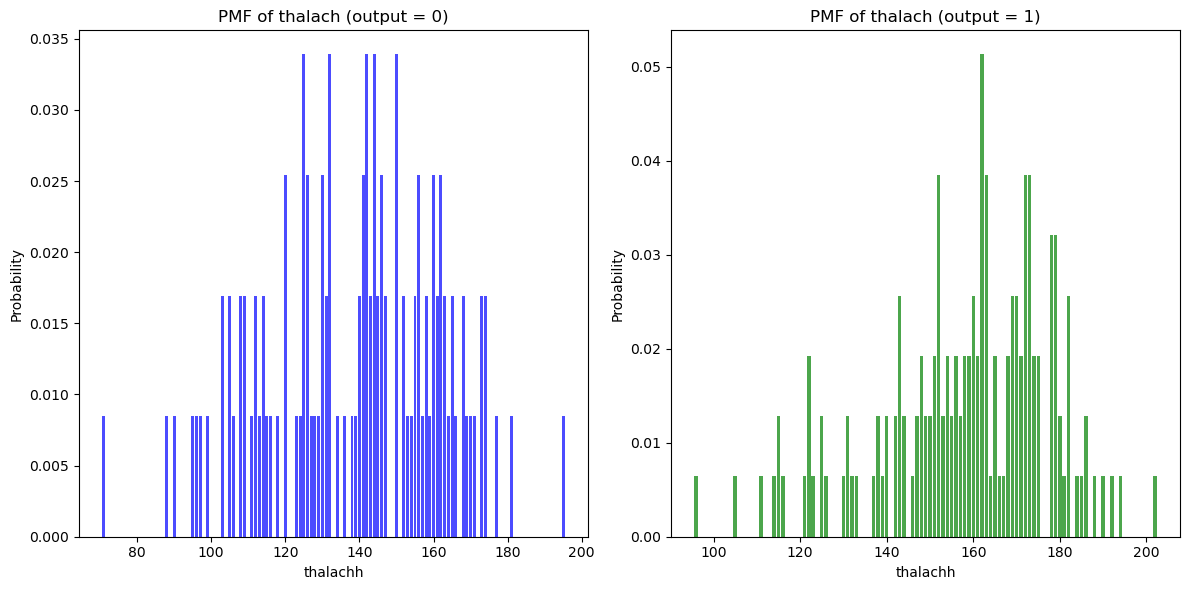

In [7]:
# Split the data based on the 'output' column
thalachh_output_0 = df[df['output'] == 0]['thalachh']
thalachh_output_1 = df[df['output'] == 1]['thalachh']

# Function to calculate PMF
def compute_pmf(data):
    pmf = data.value_counts().sort_index() / len(data)
    return pmf

# Calculate PMFs for both scenarios
pmf_output_0 = compute_pmf(thalachh_output_0)
pmf_output_1 = compute_pmf(thalachh_output_1)

# Plot the PMFs
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.bar(pmf_output_0.index, pmf_output_0.values, color='blue', alpha=0.7)
plt.title('PMF of thalach (output = 0)')
plt.xlabel('thalachh')
plt.ylabel('Probability')

plt.subplot(1, 2, 2)
plt.bar(pmf_output_1.index, pmf_output_1.values, color='green', alpha=0.7)
plt.title('PMF of thalach (output = 1)')
plt.xlabel('thalachh')
plt.ylabel('Probability')

plt.tight_layout()
plt.show()

There doesn't seem to be a big difference between the 2 graphs.

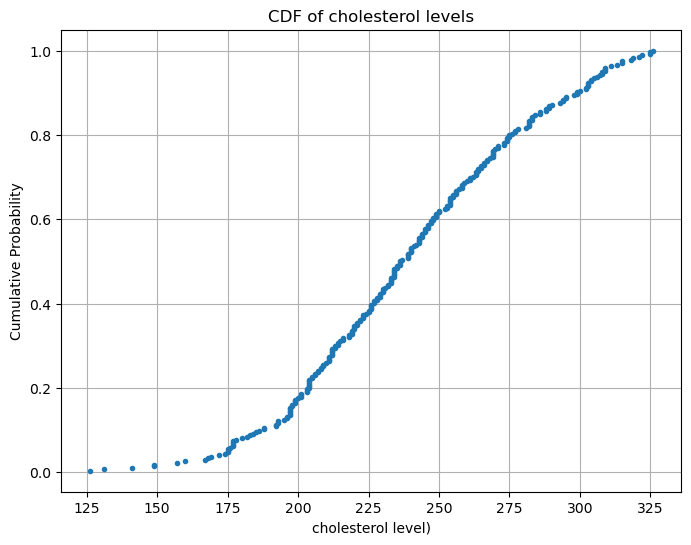

In [8]:
chol_sorted = np.sort(df['chol'])

# Calculate the CDF
cdf = np.arange(1, len(chol_sorted) + 1) / len(chol_sorted)

# Plot the CDF
plt.figure(figsize=(8, 6))
plt.plot(chol_sorted, cdf, marker='.', linestyle='none')
plt.title('CDF of cholesterol levels')
plt.xlabel('cholesterol level)')
plt.ylabel('Cumulative Probability')
plt.grid(True)
plt.show()

The steep slope suggests that most data values are clustered together in the middle of the graph

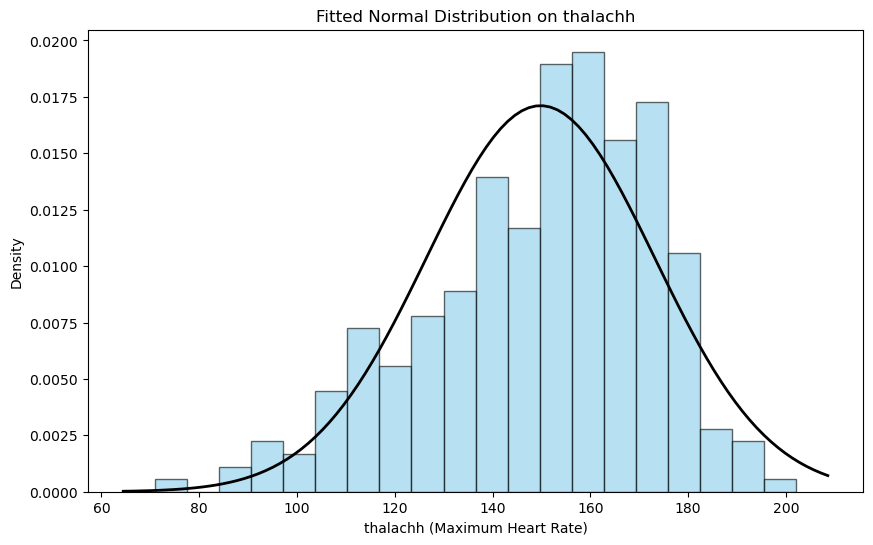

Fitted Normal Distribution: mean = 149.80, standard deviation = 23.31


In [9]:
# Choose the variable 'thalach' (Maximum Heart Rate)
thalachh_data = df['thalachh']

# Fit a normal distribution to the data
mu, std = norm.fit(thalachh_data)

# Plot the histogram of the data
plt.figure(figsize=(10, 6))
plt.hist(thalachh_data, bins=20, density=True, alpha=0.6, color='skyblue', edgecolor='black')

# Plot the fitted normal distribution
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2)

# Add labels and title
plt.title('Fitted Normal Distribution on thalachh')
plt.xlabel('thalachh (Maximum Heart Rate)')
plt.ylabel('Density')

# Display the plot
plt.show()

# Print the fitted parameters
print(f'Fitted Normal Distribution: mean = {mu:.2f}, standard deviation = {std:.2f}')

**Distribution analysis**

The data shows a unimodal distribution with a peak around the mean. The general shape suggests that the data roughly follows a normal distribution, especially around the central values.
* Skewness: The histogram appears to be slightly skewed to the left (negatively skewed). The left tail is slightly longer than the right tail, indicating that there are a few individuals with significantly lower heart rates.
* Fit Quality: The fitted normal curve does a decent job at modeling the central portion of the data, but it slightly overestimates the density in the tails. This suggests that while the normal distribution is a reasonable approximation, it might not capture all aspects of the data perfectly, particularly in the extreme values.
* Mean and Spread: The mean of the distribution likely falls around the peak of the histogram, which seems to be near 150 bpm. The spread (standard deviation) is consistent with the width of the histogram.

**Application to the Dataset**

* Statistical Inference: If the normal distribution reasonably fits the data, it supports the use of parametric statistical tests that assume normality, such as t-tests or ANOVA.
* Interpretation: The slight skewness might reflect a real-world trend where a few individuals in the dataset have significantly lower maximum heart rates, potentially due to age, fitness level, or other health factors.

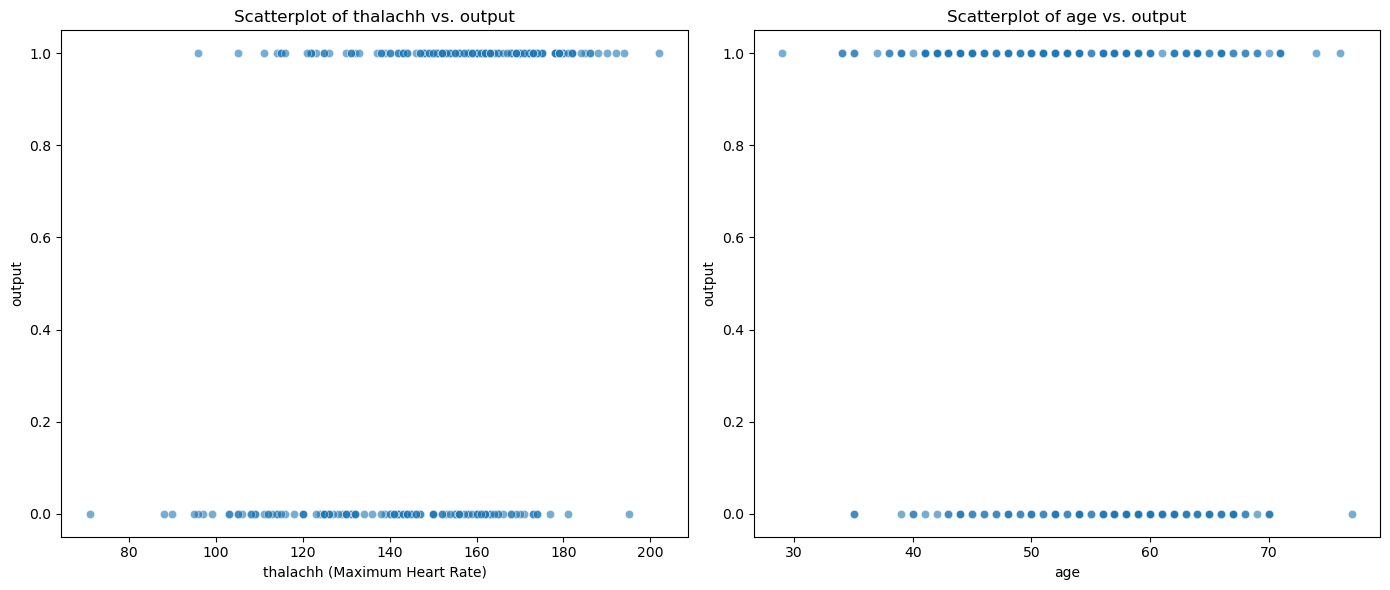

Covariance between thalachh and output: 4.84
Pearson correlation between thalachh and output: 0.42
Covariance between age and output: -1.10
Pearson correlation between age and output: -0.24


In [10]:
# plot scatterplot 1 : thalachh vs output
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x='thalachh', y='output', data=df, alpha=0.6)
plt.title('Scatterplot of thalachh vs. output')
plt.xlabel('thalachh (Maximum Heart Rate)')
plt.ylabel('output')

# Scatterplot 2: age vs. output
plt.subplot(1, 2, 2)
sns.scatterplot(x='age', y='output', data=df, alpha=0.6)
plt.title('Scatterplot of age vs. output')
plt.xlabel('age')
plt.ylabel('output')

plt.tight_layout()
plt.show()

# Covariance and Pearson's Correlation
cov_thalachh_output = df[['thalachh', 'output']].cov().iloc[0, 1]
corr_thalachh_output, _ = pearsonr(df['thalachh'], df['output'])

cov_age_output = df[['age', 'output']].cov().iloc[0, 1]
corr_age_output, _ = pearsonr(df['age'], df['output'])

print(f'Covariance between thalachh and output: {cov_thalachh_output:.2f}')
print(f'Pearson correlation between thalachh and output: {corr_thalachh_output:.2f}')
print(f'Covariance between age and output: {cov_age_output:.2f}')
print(f'Pearson correlation between age and output: {corr_age_output:.2f}')

The positive covariance suggests that there’s a tendency for thalachh and output to increase together. The Pearson correlation of 0.42 indicates a moderate positive linear relationship. In the scatterplot, you would likely see a general upward trend, where higher thalachh values are associated with higher output values

The negative covariance suggests that as age increases, output tends to decrease. The Pearson correlation of -0.23 indicates a weak negative linear relationship. In the scatterplot, you might see a slight downward trend, where older ages are somewhat associated with lower output values, but the relationship is not strong

In [11]:
# Hypothesis testing
# Separate the data based on 'output' value
group_0 = df[df['output'] == 0]
group_1 = df[df['output'] == 1]

# Perform t-tests for thalachh and age
t_stat_thalachh, p_val_thalachh = ttest_ind(group_0['thalachh'], group_1['thalachh'])
t_stat_age, p_val_age = ttest_ind(group_0['age'], group_1['age'])
t_stat_trtbps, p_val_trtbps = ttest_ind(group_0['trtbps'], group_1['trtbps'])
t_stat_chol, p_val_chol = ttest_ind(group_0['chol'], group_1['chol'])
t_stat_oldpeak, p_val_oldpeak = ttest_ind(group_0['oldpeak'], group_1['oldpeak'])
# Print results
print(f"t-statistic for thalachh: {t_stat_thalachh:.2f}, p-value: {p_val_thalachh:.5f}")
print(f"t-statistic for age: {t_stat_age:.2f}, p-value: {p_val_age:.5f}")
print(f"t-statistic for chol: {t_stat_chol:.2f}, p-value: {p_val_chol:.5f}")
print(f"t-statistic for trtbps: {t_stat_trtbps:.2f}, p-value: {p_val_trtbps:.5f}")
print(f"t-statistic for oldpeak: {t_stat_oldpeak:.2f}, p-value: {p_val_oldpeak:.5f}")

# Conclusion based on p-values
alpha = 0.05
if p_val_thalachh < alpha:
    print("Reject the null hypothesis for thalachh: thalachh is significantly associated with heart attacks.")
else:
    print("Fail to reject the null hypothesis for thalachh: thalachh is not significantly associated with heart attacks.")

if p_val_age < alpha:
    print("Reject the null hypothesis for age: age is significantly associated with heart attacks.")
else:
    print("Fail to reject the null hypothesis for age: age is not significantly associated with heart attacks.")

if p_val_chol < alpha:
    print("Reject the null hypothesis for chol: cholesterol is significantly associated with heart attacks.")
else:
    print("Fail to reject the null hypothesis for chol: cholesterol is not significantly associated with heart attacks.")

if p_val_trtbps < alpha:
    print("Reject the null hypothesis for trtbps: blood pressure is significantly associated with heart attacks.")
else:
    print("Fail to reject the null hypothesis for trtbps: blood pressure is not significantly associated with heart attacks.")

if p_val_oldpeak < alpha:
    print("Reject the null hypothesis for oldpeak: oldpeak is significantly associated with heart attacks.")
else:
    print("Fail to reject the null hypothesis for oldpeak: oldpeak is not significantly associated with heart attacks.")






t-statistic for thalachh: -7.58, p-value: 0.00000
t-statistic for age: 4.09, p-value: 0.00006
t-statistic for chol: 1.88, p-value: 0.06118
t-statistic for trtbps: 2.23, p-value: 0.02641
t-statistic for oldpeak: 7.53, p-value: 0.00000
Reject the null hypothesis for thalachh: thalachh is significantly associated with heart attacks.
Reject the null hypothesis for age: age is significantly associated with heart attacks.
Fail to reject the null hypothesis for chol: cholesterol is not significantly associated with heart attacks.
Reject the null hypothesis for trtbps: blood pressure is significantly associated with heart attacks.
Reject the null hypothesis for oldpeak: oldpeak is significantly associated with heart attacks.


In [12]:
# Define the explanatory variables
X = df[['thalachh', 'age']]
y = df['output']

# Add a constant to the model (intercept)
X = sm.add_constant(X)

# Fit the logistic regression model
model = sm.Logit(y, X)
result = model.fit()

# Print the summary
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.586532
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                 output   No. Observations:                  274
Model:                          Logit   Df Residuals:                      271
Method:                           MLE   Df Model:                            2
Date:                Fri, 09 Aug 2024   Pseudo R-squ.:                  0.1419
Time:                        16:48:57   Log-Likelihood:                -160.71
converged:                       True   LL-Null:                       -187.28
Covariance Type:            nonrobust   LLR p-value:                 2.892e-12
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -4.2636      1.555     -2.742      0.006      -7.311      -1.216
thalachh       0.0388      0.

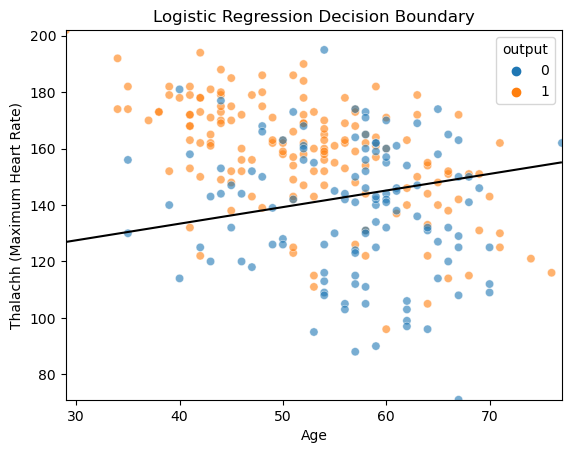

In [13]:
# graph logistic regression results

# Extract coefficients
intercept = result.params['const']
coef_age = result.params['age']
coef_thalachh = result.params['thalachh']

# Create a grid of age and thalachh values
age_grid = np.linspace(df['age'].min(), df['age'].max(), 100)
thalachh_grid = np.linspace(df['thalachh'].min(), df['thalachh'].max(), 100)
xx, yy = np.meshgrid(age_grid, thalachh_grid)

# Calculate predicted probabilities
Z = intercept + coef_age * xx + coef_thalachh * yy
predicted_probs = np.exp(Z) / (1 + np.exp(Z))

# Plot the decision boundary (where predicted probability = 0.5)
plt.contour(xx, yy, predicted_probs, levels=[0.5], colors='black')

# Scatter plot of the data points
sns.scatterplot(x='age', y='thalachh', data=df, hue='output', alpha=0.6)

# Set title and labels
plt.title('Logistic Regression Decision Boundary')
plt.xlabel('Age')
plt.ylabel('Thalachh (Maximum Heart Rate)')

# Show the plot
plt.show()


## Model analysis

The results strongly suggest that the maximum heart rate (thalachh) is significantly associated with the likelihood of a heart attack. As thalachh increases, the risk of heart attack also increases.

While age has a negative coefficient, it is not statistically significant in this model. This suggests that when accounting for thalachh, age may not have a strong or independent effect on heart attack risk in this dataset.

The overall model fits the data reasonably well, as indicated by the pseudo R-squared value and the significance of the overall model.